In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy import stats
from scipy.stats import zscore
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import train_test_split

In [ ]:
# URL of the dataset
dataset_url = "http://kdd.ics.uci.edu/databases/kddcup99/kddcup.data_10_percent.gz" # 10% of the dataset
# dataset_url  = "http://kdd.ics.uci.edu/databases/kddcup99/kddcup.data.gz" # Full dataset

In [ ]:
# URL of the dataset
url = "http://kdd.ics.uci.edu/databases/kddcup99/kddcup.data_10_percent.gz"
# url = "http://kdd.ics.uci.edu/databases/kddcup99/kddcup.data.gz"

# 41 Features + 1 attack type
feature_names = [
    "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes", "land", "wrong_fragment", "urgent",
    "hot", "num_failed_logins", "logged_in", "num_compromised", "root_shell", "su_attempted", "num_root",
    "num_file_creations", "num_shells", "num_access_files", "num_outbound_cmds", "is_host_login", "is_guest_login",
    "count", "srv_count", "serror_rate", "srv_serror_rate", "rerror_rate", "srv_rerror_rate", "same_srv_rate",
    "diff_srv_rate", "srv_diff_host_rate", "dst_host_count", "dst_host_srv_count", "dst_host_same_srv_rate",
    "dst_host_diff_srv_rate", "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate", "dst_host_serror_rate",
    "dst_host_srv_serror_rate", "dst_host_rerror_rate", "dst_host_srv_rerror_rate", "attack_type"
]

In [ ]:
# Load the dataset into a pandas DataFrame
df = pd.read_csv(url, header=None, names=feature_names)

# DataFrame Visualization
df

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack_type
0,0,tcp,http,SF,181,5450,0,0,0,0,...,9,1.0,0.0,0.11,0.00,0.00,0.00,0.0,0.0,normal.
1,0,tcp,http,SF,239,486,0,0,0,0,...,19,1.0,0.0,0.05,0.00,0.00,0.00,0.0,0.0,normal.
2,0,tcp,http,SF,235,1337,0,0,0,0,...,29,1.0,0.0,0.03,0.00,0.00,0.00,0.0,0.0,normal.
3,0,tcp,http,SF,219,1337,0,0,0,0,...,39,1.0,0.0,0.03,0.00,0.00,0.00,0.0,0.0,normal.
4,0,tcp,http,SF,217,2032,0,0,0,0,...,49,1.0,0.0,0.02,0.00,0.00,0.00,0.0,0.0,normal.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
494016,0,tcp,http,SF,310,1881,0,0,0,0,...,255,1.0,0.0,0.01,0.05,0.00,0.01,0.0,0.0,normal.
494017,0,tcp,http,SF,282,2286,0,0,0,0,...,255,1.0,0.0,0.17,0.05,0.00,0.01,0.0,0.0,normal.
494018,0,tcp,http,SF,203,1200,0,0,0,0,...,255,1.0,0.0,0.06,0.05,0.06,0.01,0.0,0.0,normal.
494019,0,tcp,http,SF,291,1200,0,0,0,0,...,255,1.0,0.0,0.04,0.05,0.04,0.01,0.0,0.0,normal.


In [ ]:
# Identify columns with only one unique value
single_value_cols = df.columns[df.nunique() == 1]

# Print columns to be dropped
print("Columns dropped due to only one unique value:", list(single_value_cols))

# Drop these columns from the dataframe
df = df.drop(columns=single_value_cols)

Columns dropped due to only one unique value: ['num_outbound_cmds', 'is_host_login']


# Exploratory Data Analysis - Before processing

In [ ]:
df.describe()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
count,494021.000000,4.940210e+05,4.940210e+05,494021.000000,494021.000000,494021.000000,494021.000000,494021.000000,494021.000000,494021.000000,...,494021.000000,494021.000000,494021.000000,494021.000000,494021.000000,494021.000000,494021.000000,494021.000000,494021.000000,494021.000000
mean,47.979302,3.025610e+03,8.685324e+02,0.000045,0.006433,0.000014,0.034519,0.000152,0.148247,0.010212,...,232.470778,188.665670,0.753780,0.030906,0.601935,0.006684,0.176754,0.176443,0.058118,0.057412
std,707.746472,9.882181e+05,3.304000e+04,0.006673,0.134805,0.005510,0.782103,0.015520,0.355345,1.798326,...,64.745380,106.040437,0.410781,0.109259,0.481309,0.042133,0.380593,0.380919,0.230590,0.230140
min,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,4.500000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,255.000000,46.000000,0.410000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,5.200000e+02,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,255.000000,255.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,1.032000e+03,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,255.000000,255.000000,1.000000,0.040000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,58329.000000,6.933756e+08,5.155468e+06,1.000000,3.000000,3.000000,30.000000,5.000000,1.000000,884.000000,...,255.000000,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


#### Missing Values Analysis

In [ ]:
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 348435


In [ ]:
df.info()
# The dataset does not contain any missing values. All columns have complete data for all 494,021 entries.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 494021 entries, 0 to 494020
Data columns (total 40 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     494021 non-null  int64  
 1   protocol_type                494021 non-null  object 
 2   service                      494021 non-null  object 
 3   flag                         494021 non-null  object 
 4   src_bytes                    494021 non-null  int64  
 5   dst_bytes                    494021 non-null  int64  
 6   land                         494021 non-null  int64  
 7   wrong_fragment               494021 non-null  int64  
 8   urgent                       494021 non-null  int64  
 9   hot                          494021 non-null  int64  
 10  num_failed_logins            494021 non-null  int64  
 11  logged_in                    494021 non-null  int64  
 12  num_compromised              494021 non-null  int64  
 13 

#### Distribution Analysis with Histograms

Feature: attack_type


,Count,count
0,smurf.,280790
1,neptune.,107201
2,normal.,97278
3,back.,2203
4,satan.,1589
5,ipsweep.,1247
6,portsweep.,1040
7,warezclient.,1020
8,teardrop.,979
9,pod.,264


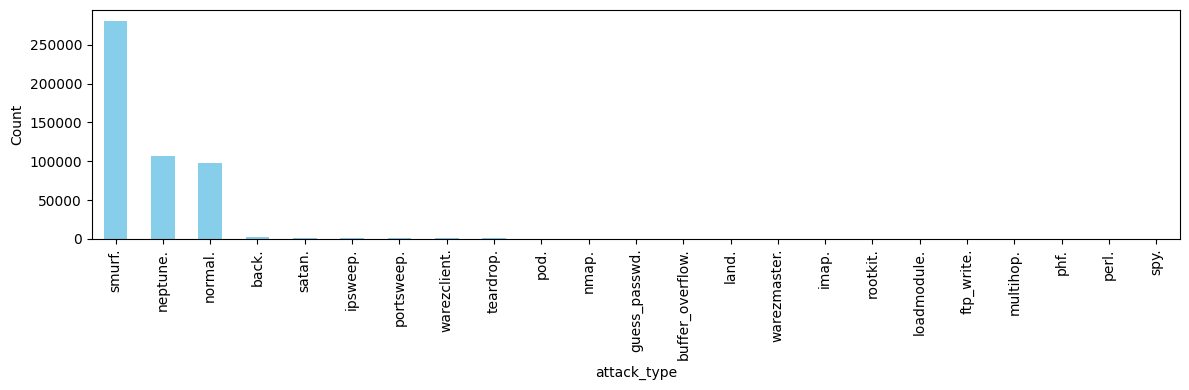



Feature: protocol_type


,Count,count
0,icmp,283602
1,tcp,190065
2,udp,20354


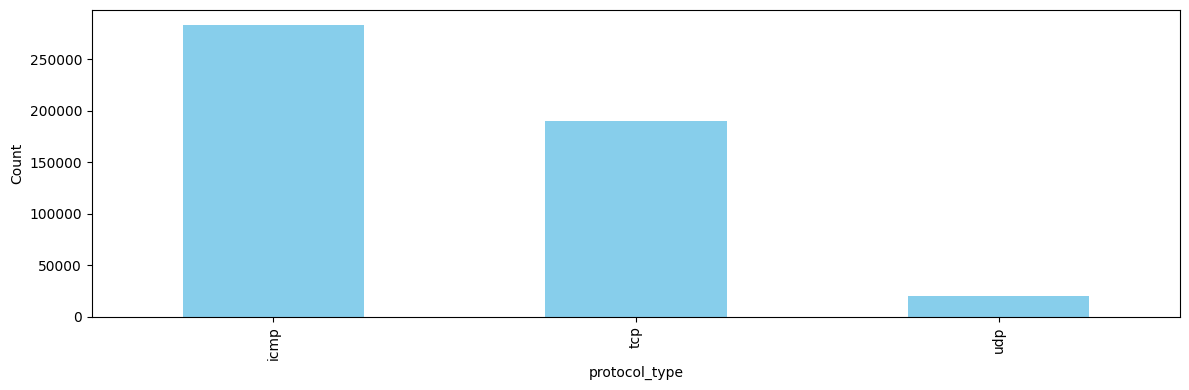



Feature: service


,Count,count
0,ecr_i,281400
1,private,110893
2,http,64293
3,smtp,9723
4,other,7237
...,...,...
61,X11,11
62,tim_i,7
63,pm_dump,1
64,tftp_u,1


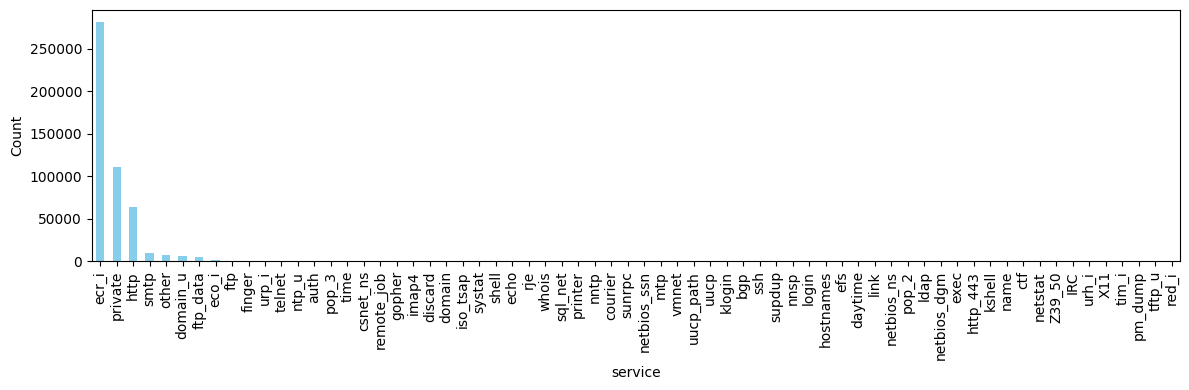

,Count,count
0,SF,378440
1,S0,87007
2,REJ,26875
3,RSTR,903
4,RSTO,579
5,SH,107
6,S1,57
7,S2,24
8,RSTOS0,11
9,S3,10




Feature: flag


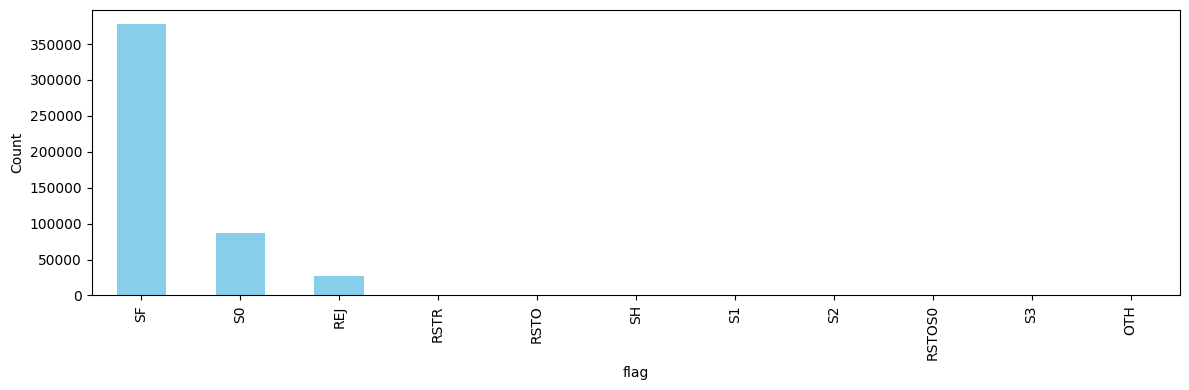

In [ ]:
categorical_features = ["attack_type", "protocol_type", "service", "flag"]

# Display histogram of categorical features in a structured format
for feature in categorical_features:
    # Display value counts in a structured table format
    print(f"Feature: {feature}")
    display(df[feature].value_counts().reset_index().rename(columns={'index': 'Category', feature: 'Count'}))

    # Draw histogram with a more compact figure size
    plt.figure(figsize=(12, 4))  # Adjusted to fit well below the table
    df[feature].value_counts().plot(kind='bar', color='skyblue')
    plt.xlabel(feature)
    plt.ylabel("Count")
    # plt.xticks(rotation=60)  # Rotate x-tick labels if categories have long names
    plt.tight_layout()       # Adjust layout to avoid clipping
    plt.show()
    print("\n")

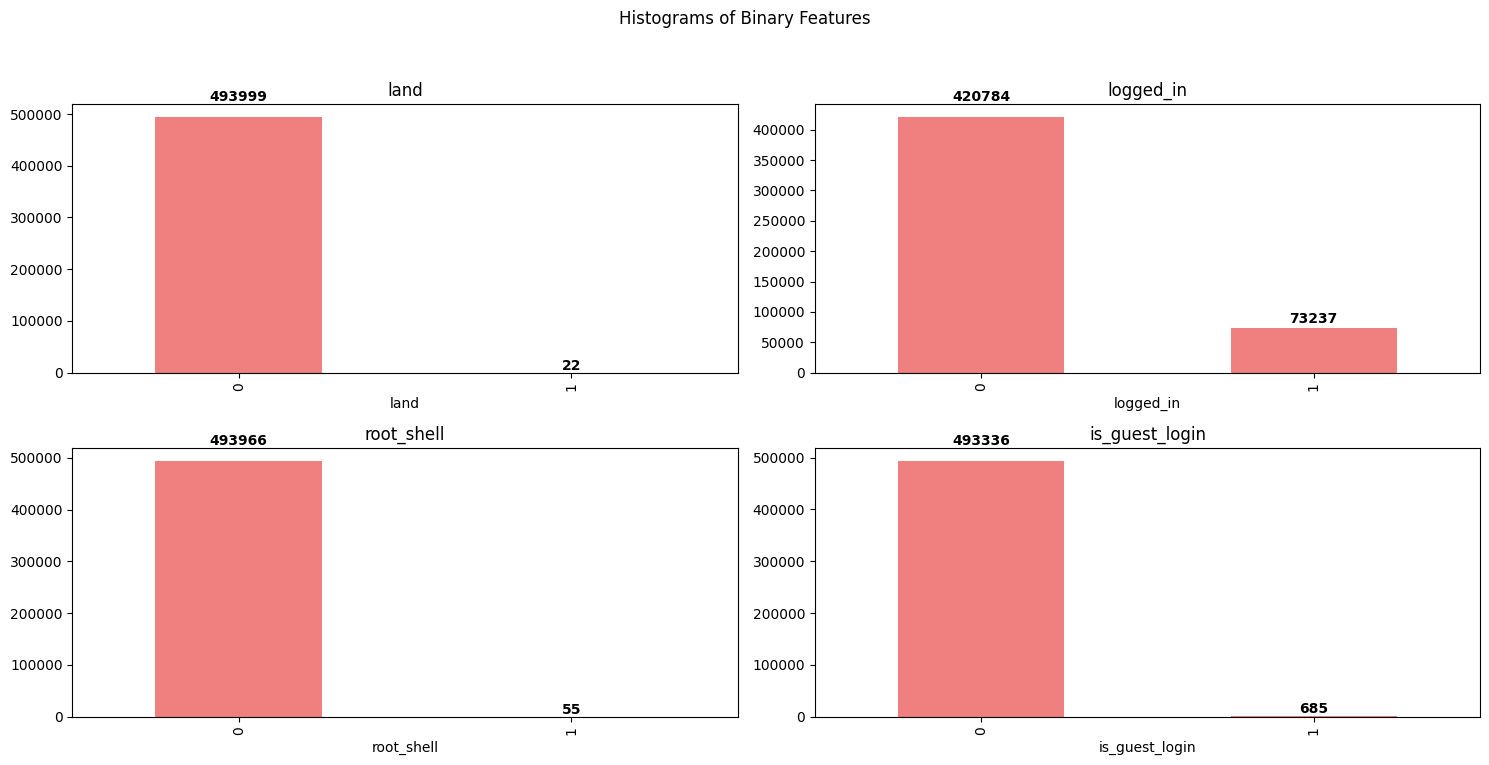

In [ ]:
# List of binary features
binary_features = ['land', 'logged_in', 'root_shell', 'is_guest_login']

# Set up a 2x3 grid for the binary feature histograms
fig, axes = plt.subplots(2, 2, figsize=(15, 8))
fig.suptitle("Histograms of Binary Features")

# Plot each binary feature in the 2x3 grid
for i, feature in enumerate(binary_features):
    ax = axes[i // 2, i % 2]  # Determine the position in 2x3 grid
    value_counts = df[feature].value_counts()

    # Plot the bar chart
    value_counts.plot(kind='bar', ax=ax, color='lightcoral')
    ax.set_title(feature)
    ax.set_xticks([0, 1])  # Ensure binary values 0 and 1 are shown as ticks

    # Add count labels on top of each bar
    for x, count in enumerate(value_counts):
        ax.text(x, count + 0.05 * count, str(count), ha='center', va='bottom', fontsize=10, fontweight='bold')

# Adjust layout to prevent overlapping elements
plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust layout to fit the main title
plt.show()

Highly correlated feature pairs:
num_root and num_compromised: 0.99
is_guest_login and hot: 0.84
srv_count and count: 0.94
srv_serror_rate and serror_rate: 1.00
srv_rerror_rate and rerror_rate: 0.99
same_srv_rate and serror_rate: 0.86
same_srv_rate and srv_serror_rate: 0.86
dst_host_srv_count and same_srv_rate: 0.90
dst_host_same_srv_rate and same_srv_rate: 0.93
dst_host_same_srv_rate and dst_host_srv_count: 0.97
dst_host_same_src_port_rate and count: 0.86
dst_host_same_src_port_rate and srv_count: 0.94
dst_host_serror_rate and serror_rate: 1.00
dst_host_serror_rate and srv_serror_rate: 1.00
dst_host_serror_rate and same_srv_rate: 0.86
dst_host_serror_rate and dst_host_same_srv_rate: 0.80
dst_host_srv_serror_rate and serror_rate: 1.00
dst_host_srv_serror_rate and srv_serror_rate: 1.00
dst_host_srv_serror_rate and same_srv_rate: 0.86
dst_host_srv_serror_rate and dst_host_serror_rate: 1.00
dst_host_rerror_rate and rerror_rate: 0.99
dst_host_rerror_rate and srv_rerror_rate: 0.98
dst_host_

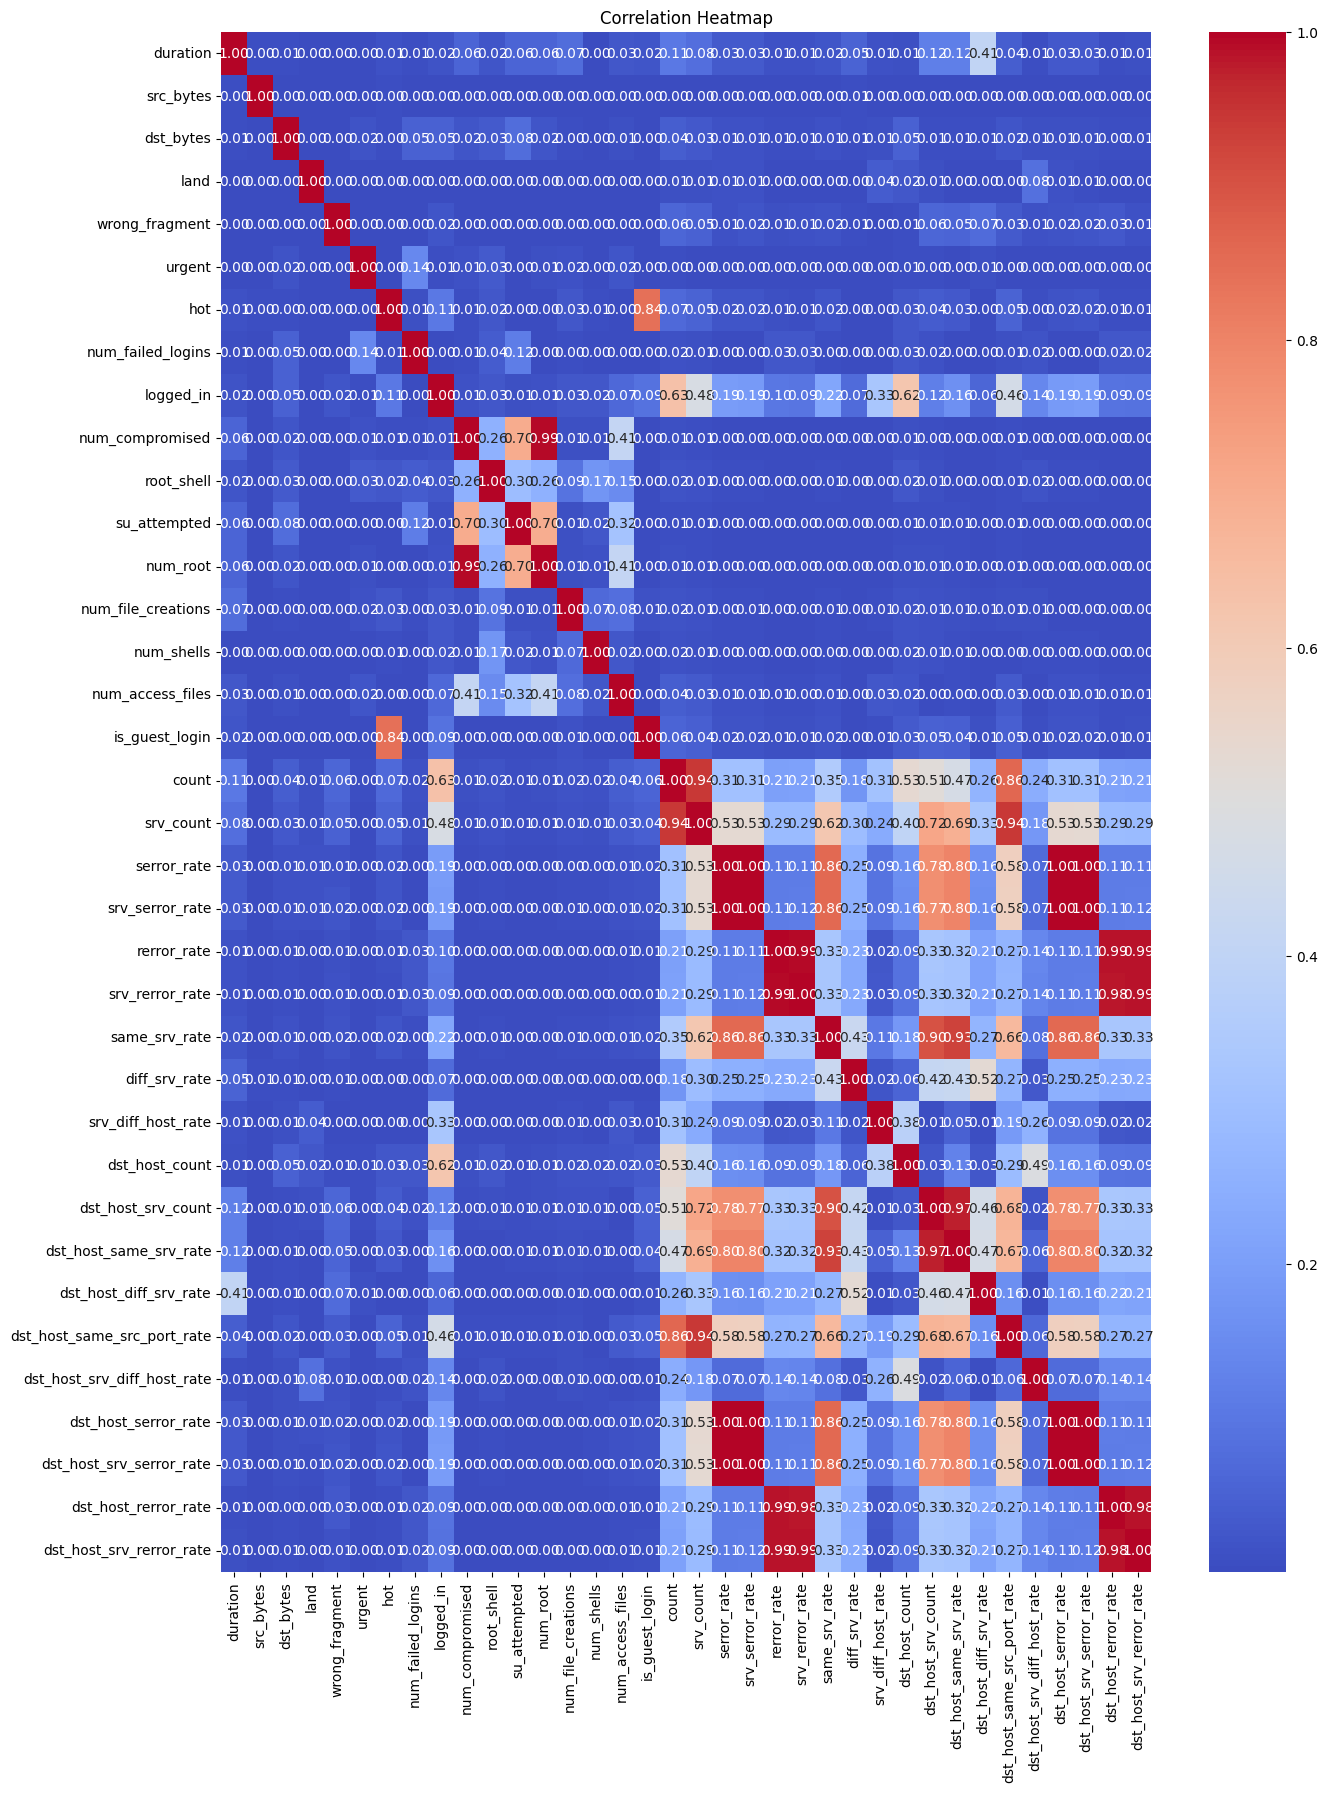

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming df is your DataFrame
# Select only numeric features
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# Calculate the correlation matrix
correlation_matrix = numeric_df.corr().abs()

# Set the threshold for high correlation
threshold = 0.8

# Find pairs of highly correlated features
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i):
        if abs(correlation_matrix.iloc[i, j]) > threshold:
            high_corr_pairs.append((correlation_matrix.columns[i], correlation_matrix.columns[j], correlation_matrix.iloc[i, j]))

# Print the highly correlated pairs
print("Highly correlated feature pairs:")
for pair in high_corr_pairs:
    print(f"{pair[0]} and {pair[1]}: {pair[2]:.2f}")

# Visualize the correlation matrix
plt.figure(figsize=(15, 20))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


# PreProcessing

####  Handle Missing Values
 Remove Rows with Missing Values

In [ ]:
df.dropna(inplace = True)

Removing Duplicate Data

In [ ]:
df_cleaned = df.drop_duplicates()
print(f"Shape after removing duplicates: {df_cleaned.shape}")

Shape after removing duplicates: (145586, 40)


Handling Outliers

In [ ]:
# Define numerical features based on the current DataFrame
numerical_features = [col for col in [
    "duration", "src_bytes", "dst_bytes", "num_failed_logins", "num_compromised",
    "num_file_creations", "num_shells", "num_access_files", "count", "srv_count",
    "serror_rate", "srv_serror_rate", "rerror_rate", "srv_rerror_rate",
    "same_srv_rate", "diff_srv_rate", "srv_diff_host_rate", "dst_host_count",
    "dst_host_srv_count", "dst_host_same_srv_rate", "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate", "dst_host_srv_serror_rate", "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate", "num_outbound_cmds"
] if col in df_cleaned.columns]
z_scores = np.abs(stats.zscore(df_cleaned[numerical_features]))
outliers = (z_scores > 3)
print(f"Number of outliers detected per feature:\n{outliers.sum(axis=0)}")
df_no_outliers = df_cleaned[(~outliers).all(axis=1)]
print(f"Shape after removing outliers: {df_no_outliers.shape}")

Number of outliers detected per feature:
duration                       1596
src_bytes                         1
dst_bytes                       121
num_failed_logins                63
num_compromised                  14
num_file_creations              265
num_shells                       51
num_access_files                453
count                           978
srv_count                      1630
serror_rate                       0
srv_serror_rate                   0
rerror_rate                       0
srv_rerror_rate                   0
same_srv_rate                     0
diff_srv_rate                  3055
srv_diff_host_rate             7587
dst_host_count                    0
dst_host_srv_count                0
dst_host_same_srv_rate            0
dst_host_diff_srv_rate         5286
dst_host_same_src_port_rate    8348
dst_host_srv_diff_host_rate    2273
dst_host_serror_rate              0
dst_host_srv_serror_rate          0
dst_host_rerror_rate              0
dst_host_srv_rerror_rat

#### Balancing Data

In [ ]:
df_encoded = pd.get_dummies(df_no_outliers, columns=["protocol_type", "service", "flag"], drop_first=True)

df_binary = df_encoded.copy()

df_binary['attack_type'] = df_binary['attack_type'].apply(lambda x: 'normal' if x == 'normal.' else 'attack')

df_binary['attack_type'] = df_binary['attack_type'].map({'normal': 0, 'attack': 1})

print(df_binary['attack_type'].value_counts())

# Separate features and target variable
X = df_binary.drop('attack_type', axis=1)
y = df_binary['attack_type']

# Split data into training and test sets (optional but recommended)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Apply SMOTE to the training set
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X,y)

# Check the distribution of the classes after applying SMOTE
print("Balanced class distribution:\n", y_train_balanced.value_counts())

attack_type
0    71124
1    53814
Name: count, dtype: int64
Balanced class distribution:
 attack_type
0    71124
1    71124
Name: count, dtype: int64


#### Removing highly correlated features

In [ ]:
# List of features to drop based on high correlation
features_to_drop = [
    "num_compromised", "hot", "srv_count", "serror_rate",
    "rerror_rate", "same_srv_rate", "dst_host_srv_count",
    "dst_host_same_srv_rate",
    "dst_host_serror_rate", "dst_host_srv_serror_rate",
    "dst_host_rerror_rate", "dst_host_srv_rerror_rate"
]

# Remove the features from the dataset
df_cleaned = df_binary.drop(columns=features_to_drop)

# Verify the dimensions of the cleaned dataset
print("Shape before removing correlated features:", df_binary.shape)
print("Shape after removing correlated features:", df_cleaned.shape)


Shape before removing correlated features: (124938, 111)
Shape after removing correlated features: (124938, 99)


# Exploratory Data Analysis - After processing

Index(['duration', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment',
       'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised',
       ...
       'service_whois', 'flag_RSTO', 'flag_RSTOS0', 'flag_RSTR', 'flag_S0',
       'flag_S1', 'flag_S2', 'flag_S3', 'flag_SF', 'attack_type'],
      dtype='object', length=111)


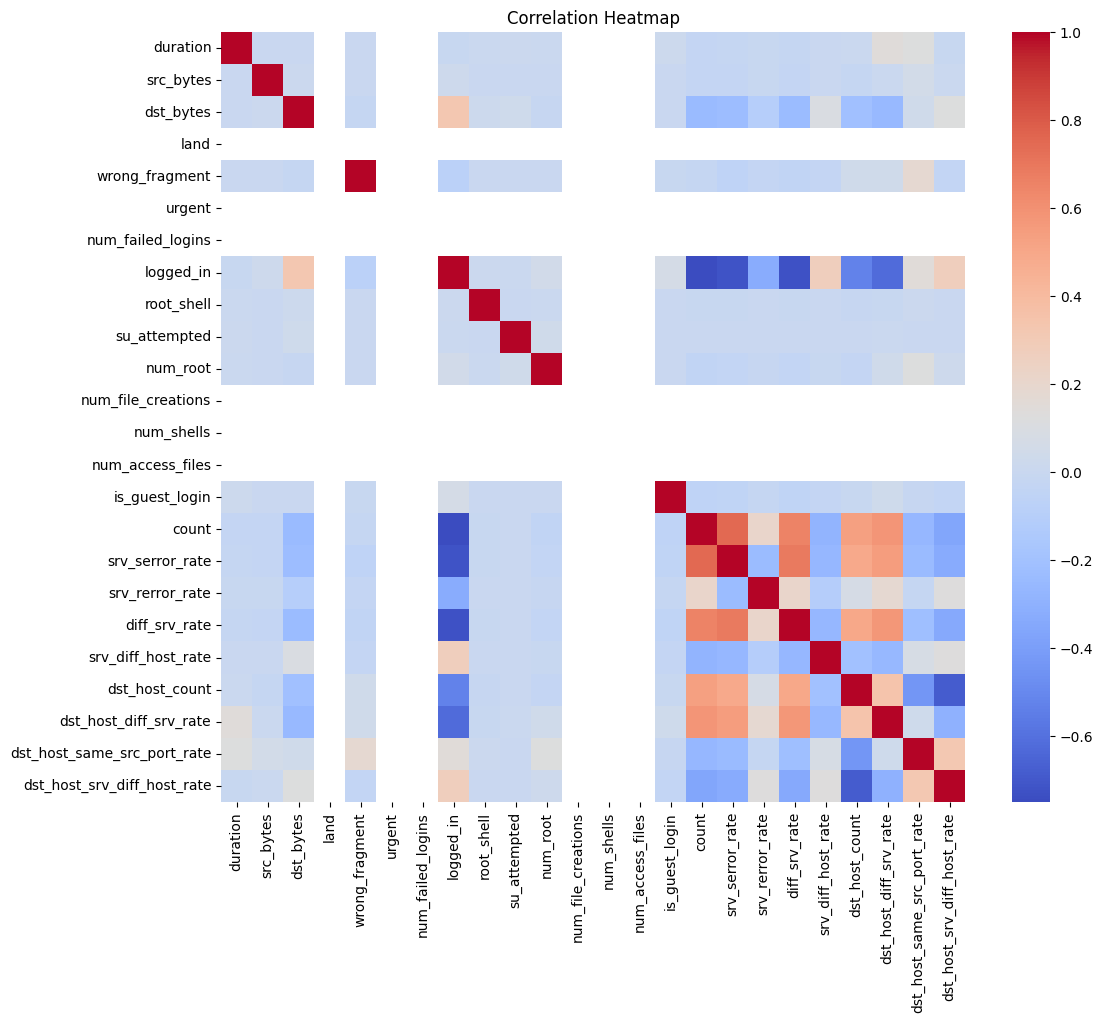

In [ ]:
# Combine features and target variable into a single DataFrame at once
df_balanced = pd.concat([pd.DataFrame(X_train_balanced, columns=X.columns),
                         pd.Series(y_train_balanced.values, name='attack_type')], axis=1)
numeric_df = df_cleaned.select_dtypes(include=['float64', 'int64'])
# Drop the target variable for correlation analysis
correlation_matrix = numeric_df.drop("attack_type", axis=1).corr()

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


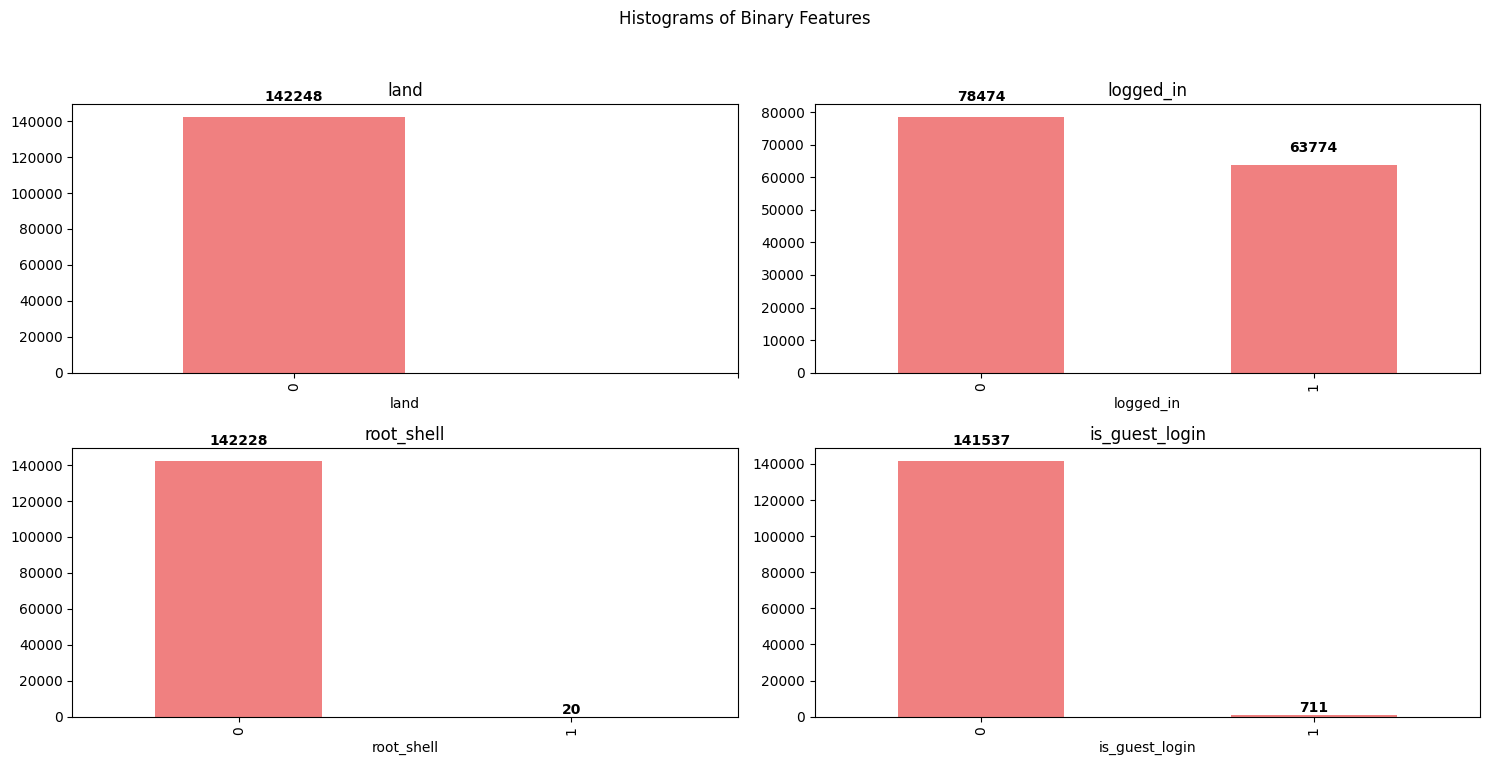

In [ ]:
# List of binary features
binary_features = ['land', 'logged_in', 'root_shell', 'is_guest_login']

# Set up a 2x3 grid for the binary feature histograms
fig, axes = plt.subplots(2, 2, figsize=(15, 8))
fig.suptitle("Histograms of Binary Features")

# Plot each binary feature in the 2x3 grid
for i, feature in enumerate(binary_features):
    ax = axes[i // 2, i % 2]  # Determine the position in 2x3 grid
    value_counts = df_balanced[feature].value_counts()

    # Plot the bar chart
    value_counts.plot(kind='bar', ax=ax, color='lightcoral')
    ax.set_title(feature)
    ax.set_xticks([0, 1])  # Ensure binary values 0 and 1 are shown as ticks

    # Add count labels on top of each bar
    for x, count in enumerate(value_counts):
        ax.text(x, count + 0.05 * count, str(count), ha='center', va='bottom', fontsize=10, fontweight='bold')

# Adjust layout to prevent overlapping elements
plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust layout to fit the main title
plt.show()

# **Hypothesis Testing**


In [ ]:
import pandas as pd
from scipy.stats import chi2_contingency

# 1. Randomly sample 5000 rows from the dataset (replace df_binary with your actual DataFrame)
sampled_df = df_binary.sample(n=5000, random_state=42)  # Ensure reproducibility with random_state

# 2. Define the one-hot encoded columns
encoded_columns = ['protocol_type_tcp', 'protocol_type_udp', 'service_ftp', 'service_http', 'flag_SF']  # Update based on actual column names

# 3. Perform Chi-square test on the dummy columns from the sampled data
for col in encoded_columns:
    # Create contingency table between the encoded column and attack_type
    contingency_table = pd.crosstab(sampled_df[col], sampled_df['attack_type'])

    # Perform the Chi-square test
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)

    # Print the results
    print(f"Chi-square test for {col} vs attack_type (on sampled data):")
    print(f"Chi2: {chi2}, p-value: {p_value}")
    if p_value < 0.05:
        print("There is a significant relationship between the feature and the target.")
    else:
        print("There is no significant relationship between the feature and the target.")
    print("-" * 50)

# After performing tests on the sampled data, you can validate results on the full dataset:
print("---- Validation on Full Dataset ----")
for col in encoded_columns:
    # Create contingency table between the encoded column and attack_type on the full dataset
    contingency_table_full = pd.crosstab(df_binary[col], df_binary['attack_type'])

    # Perform the Chi-square test on the full dataset
    chi2_full, p_value_full, dof_full, expected_full = chi2_contingency(contingency_table_full)

    # Print the results for the full dataset
    print(f"Chi-square test for {col} vs attack_type (on full dataset):")
    print(f"Chi2: {chi2_full}, p-value: {p_value_full}")
    if p_value_full < 0.05:
        print("There is a significant relationship between the feature and the target.")
    else:
        print("There is no significant relationship between the feature and the target.")
    print("-" * 50)


Chi-square test for protocol_type_tcp vs attack_type (on sampled data):
Chi2: 72.87005919727146, p-value: 1.3847302661835377e-17
There is a significant relationship between the feature and the target.
--------------------------------------------------
Chi-square test for protocol_type_udp vs attack_type (on sampled data):
Chi2: 71.87248568527411, p-value: 2.295626478397969e-17
There is a significant relationship between the feature and the target.
--------------------------------------------------
Chi-square test for service_ftp vs attack_type (on sampled data):
Chi2: 1.4293824129894475, p-value: 0.23186525544425318
There is no significant relationship between the feature and the target.
--------------------------------------------------
Chi-square test for service_http vs attack_type (on sampled data):
Chi2: 2945.803694880395, p-value: 0.0
There is a significant relationship between the feature and the target.
--------------------------------------------------
Chi-square test for flag

In [ ]:
from scipy.stats import ttest_ind

# 1. Randomly sample 5000 rows from the dataset (replace df_binary with your actual DataFrame)
sampled_df = df_binary.sample(n=5000, random_state=42)  # Ensure reproducibility with random_state

# 2. List of numerical columns to test
numerical_columns = ['duration', 'src_bytes', 'dst_bytes', 'count', 'srv_count']  # Add other numerical features

# 3. Loop over each numerical feature and perform a t-test on the sampled data
for col in numerical_columns:
    # Separate data based on attack type for the sampled data
    normal_data_sample = sampled_df[sampled_df['attack_type'] == 0][col]
    attack_data_sample = sampled_df[sampled_df['attack_type'] == 1][col]

    # Perform t-test (Welch’s t-test with unequal variances)
    t_stat_sample, p_value_sample = ttest_ind(normal_data_sample, attack_data_sample, equal_var=False)

    # Print the results for the sampled data
    print(f"T-test for {col} vs attack_type (on sampled data):")
    print(f"T-statistic: {t_stat_sample}, p-value: {p_value_sample}")
    if p_value_sample < 0.05:
        print("There is a significant difference in means between the attack and normal groups.")
    else:
        print("There is no significant difference in means between the attack and normal groups.")
    print("-" * 50)

# After performing tests on the sampled data, validate the results on the full dataset:
print("---- Validation on Full Dataset ----")
for col in numerical_columns:
    # Separate data based on attack type for the full dataset
    normal_data_full = df_binary[df_binary['attack_type'] == 0][col]
    attack_data_full = df_binary[df_binary['attack_type'] == 1][col]

    # Perform t-test (Welch’s t-test with unequal variances) on the full dataset
    t_stat_full, p_value_full = ttest_ind(normal_data_full, attack_data_full, equal_var=False)

    # Print the results for the full dataset
    print(f"T-test for {col} vs attack_type (on full dataset):")
    print(f"T-statistic: {t_stat_full}, p-value: {p_value_full}")
    if p_value_full < 0.05:
        print("There is a significant difference in means between the attack and normal groups.")
    else:
        print("There is no significant difference in means between the attack and normal groups.")
    print("-" * 50)



T-test for duration vs attack_type (on sampled data):
T-statistic: 2.301264489434406, p-value: 0.021448691386515752
There is a significant difference in means between the attack and normal groups.
--------------------------------------------------
T-test for src_bytes vs attack_type (on sampled data):
T-statistic: -0.5673504053241589, p-value: 0.5705020389083634
There is no significant difference in means between the attack and normal groups.
--------------------------------------------------
T-test for dst_bytes vs attack_type (on sampled data):
T-statistic: 23.386172061651074, p-value: 2.1116301683188294e-111
There is a significant difference in means between the attack and normal groups.
--------------------------------------------------
T-test for count vs attack_type (on sampled data):
T-statistic: -96.98959492632011, p-value: 0.0
There is a significant difference in means between the attack and normal groups.
--------------------------------------------------
T-test for srv_count

In [ ]:

X_train, X_test, y_train, y_test = train_test_split(X_train_balanced, y_train_balanced, test_size=0.2, random_state=42)

In [ ]:
# prompt: train a model using xgboost and print the accuracy, precision, recall and f1-score

import xgboost as xgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Initialize and train the XGBoost model
model = xgb.XGBClassifier(random_state=42)
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-score: {f1}")

Accuracy: 0.9995782073813708
Precision: 0.9997184486520729
Recall: 0.9994370558018436
F1-score: 0.9995777324231121


In [ ]:
from sklearn.decomposition import TruncatedSVD

# Assuming df_cleaned is your preprocessed DataFrame
# Select numerical features for CUR decomposition
numerical_cols = df_cleaned.select_dtypes(include=['number']).columns
numerical_data = df_cleaned[numerical_cols]

# Apply CUR decomposition
n_components = 10  # Choose the number of components you want to keep
svd = TruncatedSVD(n_components=n_components, random_state=42)
svd.fit(numerical_data)

# Extract C, U, and R matrices
C = svd.components_.T  # Column matrix
U = np.diag(svd.singular_values_)  # Diagonal matrix of singular values
R = svd.components_  # Row matrix

print("C matrix shape:", C.shape)
print("U matrix shape:", U.shape)
print("R matrix shape:", R.shape)

C matrix shape: (25, 10)
U matrix shape: (10, 10)
R matrix shape: (10, 25)


In [ ]:
def cur_decomposition(A, k):
    """
    Perform CUR decomposition on matrix A.

    Parameters:
    - A: numpy.ndarray, the input matrix of size (m, n)
    - k: int, the rank for approximation (number of rows/columns to select)

    Returns:
    - C: numpy.ndarray, matrix of selected columns
    - U: numpy.ndarray, the linking matrix
    - R: numpy.ndarray, matrix of selected rows
    """
    # Step 1: Compute probabilities for column and row selection
    col_norms = np.linalg.norm(A, axis=0)**2  # Column norms squared
    row_norms = np.linalg.norm(A, axis=1)**2  # Row norms squared

    col_probs = col_norms / np.sum(col_norms)  # Normalize probabilities
    row_probs = row_norms / np.sum(row_norms)  # Normalize probabilities

    # Step 2: Randomly select k columns and rows based on probabilities
    cols = np.random.choice(A.shape[1], size=k, replace=False, p=col_probs)
    rows = np.random.choice(A.shape[0], size=k, replace=False, p=row_probs)

    # Step 3: Extract the matrices C and R
    C = A[:, cols]  # Select the k columns
    R = A[rows, :]  # Select the k rows

    # Step 4: Compute W (intersection matrix)
    W = A[np.ix_(rows, cols)]

    # Step 5: Compute U using the pseudoinverse of W
    U = np.linalg.pinv(W)  # Compute the Moore-Penrose pseudoinverse

    return C, U, R


In [ ]:
C, U, R = cur_decomposition(numerical_data, 10)

# Verify CUR approximation
A_approx = C @ U @ R
print("Original Matrix (A):")
print(A)
print("\nApproximated Matrix (A_approx):")
print(A_approx)
print("\nC Matrix:")
print(C)
print("\nU Matrix:")
print(U)
print("\nR Matrix:")
print(R)

InvalidIndexError: (slice(None, None, None), array([ 2,  1, 20, 15,  0, 16,  7, 24, 10, 17]))